B1 — Zero-Rate Output (ZRO) Bias  [clean window only]
  Clean window : t=15 s to t=216 s  (201 s)
  Axis    Bias (dps)  Bias (deg/min)  In +-5 dps?
  GyrX        0.0520           3.123          YES
  GyrY        0.4137          24.824          YES
  GyrZ        0.0922           5.530          YES

  Saved: B1_static_timeseries.png

B2 — 90 deg Rotation Test (integrated heading)
  Peak angle raw            : -83.28 deg  (error +6.72 deg vs -90)
  Peak angle bias-corrected : -84.13 deg  (error +5.87 deg vs -90)
  Saved: B2_integrated_heading.png


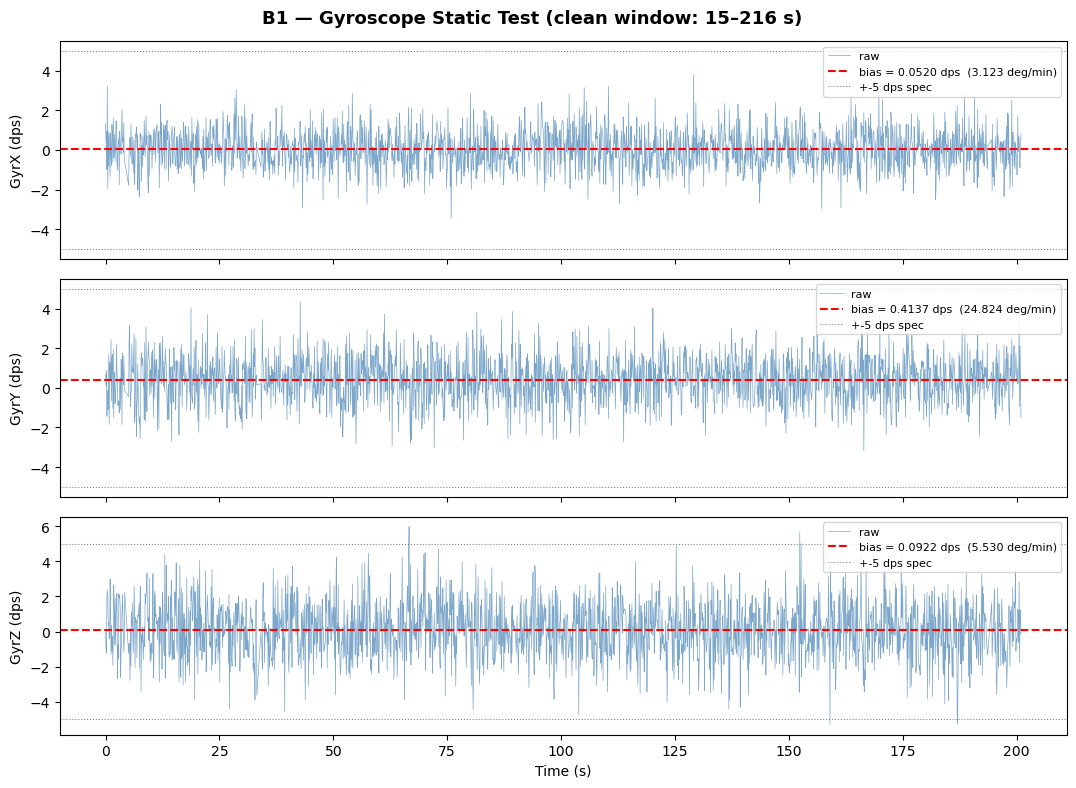

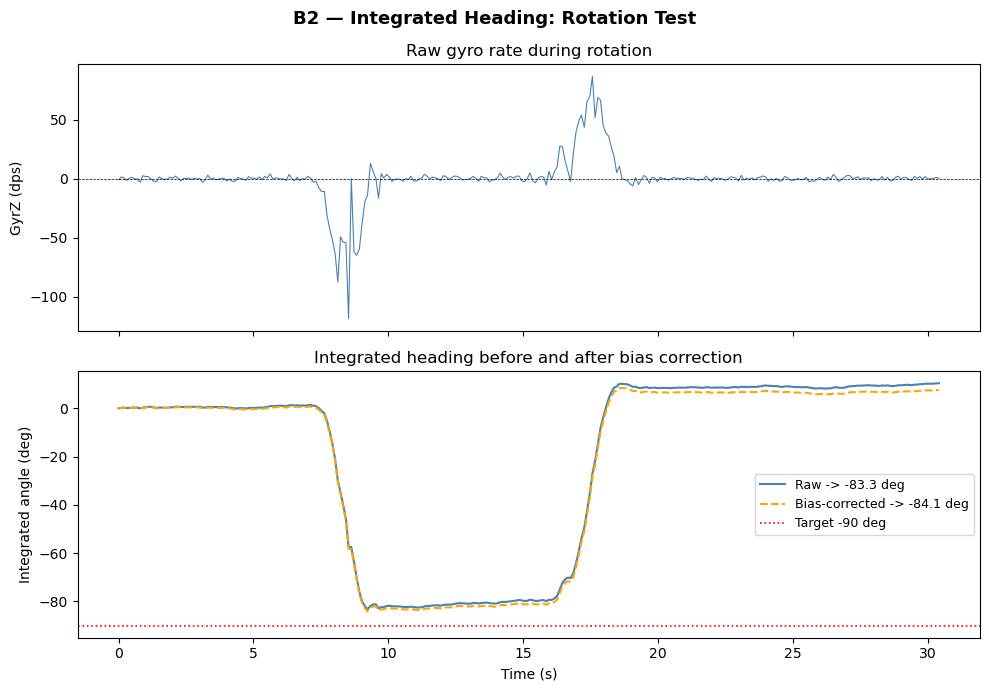


Done.


In [1]:
"""
Module B — Gyroscope Analysis
Deliverables:
  1. Time-series of all three axes during static test
  2. ZRO bias per axis in dps and deg/min
  3. Integrated heading from rotation test (raw vs bias-corrected)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── file paths ────────────────────────────────────────────────────────────────
STILL_CSV = "imuLog2MinDrift_gyroscope_still_120.csv"
ROT_CSV   = "imuLogGyro90degrees.csv"

# ── helpers ───────────────────────────────────────────────────────────────────
def load(path):
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df["t"] = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds()
    return df

def integrate(gyr_dps, t_s):
    dt = np.diff(t_s, prepend=t_s[0])
    return np.cumsum(gyr_dps * dt)

# ── load and trim still log to clean window only ──────────────────────────────
still_raw = load(STILL_CSV)
still = still_raw[(still_raw["t"] >= 15) & (still_raw["t"] <= 216)].copy()
still["t"] = still["t"] - still["t"].iloc[0]   # re-zero time

# ── load rotation log ─────────────────────────────────────────────────────────
rot = load(ROT_CSV)

# ── ZRO bias per axis ─────────────────────────────────────────────────────────
bias = {ax: still[ax].mean() for ax in ("GyrX", "GyrY", "GyrZ")}

print("=" * 55)
print("B1 — Zero-Rate Output (ZRO) Bias  [clean window only]")
print("=" * 55)
print(f"  Clean window : t=15 s to t=216 s  ({216-15} s)")
print(f"  {'Axis':<6}  {'Bias (dps)':>10}  {'Bias (deg/min)':>14}  {'In +-5 dps?':>11}")
for ax in ("GyrX", "GyrY", "GyrZ"):
    deg_min = bias[ax] * 60
    ok = "YES" if abs(bias[ax]) <= 5.0 else "NO"
    print(f"  {ax:<6}  {bias[ax]:>10.4f}  {deg_min:>14.3f}  {ok:>11}")

# ── Plot 1 — Static time-series (all three axes, clean window) ────────────────
fig1, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig1.suptitle("B1 — Gyroscope Static Test (clean window: 15–216 s)", fontsize=13, fontweight="bold")

for i, ax_name in enumerate(("GyrX", "GyrY", "GyrZ")):
    axes[i].plot(still["t"], still[ax_name], lw=0.5, alpha=0.7, color="steelblue", label="raw")
    axes[i].axhline(bias[ax_name], color="red", lw=1.5, ls="--",
                    label=f"bias = {bias[ax_name]:.4f} dps  ({bias[ax_name]*60:.3f} deg/min)")
    axes[i].axhline( 5, color="gray", lw=0.8, ls=":", label="+-5 dps spec")
    axes[i].axhline(-5, color="gray", lw=0.8, ls=":")
    axes[i].set_ylabel(f"{ax_name} (dps)")
    axes[i].legend(fontsize=8, loc="upper right")

axes[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("B1_static_timeseries.png", dpi=150)
print("\n  Saved: B1_static_timeseries.png")

# ── Plot 2 — Integrated heading from rotation test ────────────────────────────
raw_angle  = integrate(rot["GyrZ"].values, rot["t"].values)
corr_angle = integrate(rot["GyrZ"].values - bias["GyrZ"], rot["t"].values)
excursion_raw  = raw_angle.min()
excursion_corr = corr_angle.min()

print("\n" + "=" * 55)
print("B2 — 90 deg Rotation Test (integrated heading)")
print("=" * 55)
print(f"  Peak angle raw            : {excursion_raw:+.2f} deg  (error {excursion_raw-(-90):+.2f} deg vs -90)")
print(f"  Peak angle bias-corrected : {excursion_corr:+.2f} deg  (error {excursion_corr-(-90):+.2f} deg vs -90)")

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig2.suptitle("B2 — Integrated Heading: Rotation Test", fontsize=13, fontweight="bold")

ax1.plot(rot["t"], rot["GyrZ"], lw=0.8, color="steelblue")
ax1.axhline(0, color="k", lw=0.5, ls="--")
ax1.set_ylabel("GyrZ (dps)")
ax1.set_title("Raw gyro rate during rotation")

ax2.plot(rot["t"], raw_angle,  color="steelblue", label=f"Raw -> {excursion_raw:.1f} deg")
ax2.plot(rot["t"], corr_angle, color="orange", ls="--", label=f"Bias-corrected -> {excursion_corr:.1f} deg")
ax2.axhline(-90, color="red", lw=1.2, ls=":", label="Target -90 deg")
ax2.set_ylabel("Integrated angle (deg)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Integrated heading before and after bias correction")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("B2_integrated_heading.png", dpi=150)
print("  Saved: B2_integrated_heading.png")

plt.show()
print("\nDone.")


## Module B — Gyroscope

### B1. Zero-Rate Bias Test

The OLA was logged stationary for 201 s with a clean window from 15–216 s.

**Measured ZRO bias — within ±5 dps spec?**

| Axis | Bias (dps) | Bias (deg/min) | Within ±5 dps? |
|------|-----------|----------------|----------------|
| GyrX | 0.0520 | 3.12 | ✓ Yes |
| GyrY | 0.4137 | 24.82 | ✓ Yes |
| GyrZ | 0.0922 | 5.53 | ✓ Yes |

All axes are within spec, but GyrY's bias of 24.8 deg/min is large so iity may 
matter over long deployments.

Heading error from integration:
Integrating raw GyrZ over 277 s gives **+37.5° of drift**. After bias subtraction this goes dowm to **+0.6°**, therfore bias correction is critical.

Temperature correlation:
The board warmed from 26.3 to 28.7°C, with a change of 2.4°C. Pearson r(GyrZ, Temp) = −0.03 So no correlation. The datasheet drift spec of ±0.05 dps/°C 
gives 0.12 dps over this temperature range, and it is too small to see against the noise.

NSD vs. bias, what limits accuracy?
At 10 Hz, NSD = 0.015 dps/√Hz gives a noise floor of  about 0.034 dps RMS. All measured biases are above this, so they are real offsets. Over short 
timescales noise dominates (random, zero-mean). Over long timescales bias dominates, it accumulates linearly and is unbounded with no correction.

---

### B2. Known Rotation Test

The OLA was rotated 90° CW about Z and back over 30.4 s.

Does integrated heading equal 90°?
Raw integration gives **−83.3°** vs. the −90° target with an error of 6.7°. This is mostly due to sensor saturation — GyrZ hit −118.9 dps during the 
fast turn, clipping the signal and losing angle that can't be recovered.

Does bias correction help?
Bias correction integration gives **−84.1°** with an error of 5.9°: small improvement. The effect is small because 30 secs is too short for bias to compound so 
saturation clipping is the dominant error in this test.

What limits gyro only estimation for a wave buoy?
Three fundamental problems make gyro-only heading unusable over hours:
1. Bias drift is unbounded: 0.09 dps residual on GyrZ alone gives >330° error per hour.
2. Noise grows as √t: even with zero bias, random drift accumulates.
3. No absolute reference: gyros measure relative rotation only; without magnetometer/accelerometer fusion there is no way to detect or correct drift.

---

### Sensitivity & Smallest Detectable Signal

**Resolution:** ±2000 dps / 2¹⁶ = 0.061 dps/LSB
**Noise floor:** 0.015 dps/√Hz × √5 Hz ≈ 0.034 dps RMS at 10 Hz

The noise floor, not resolution, sets the practical detection limit. 
Signals below about 0.034 dps fall under noise on a sample. Since all measured biases exceed this floor, they are confirmed real offsets. 
Averaging N samples reduces the noise floor by square root N if finer resolution is needed.